# Solution: Drinking Water Demand Forecasting with Recurrent Neural Networks - Part 2
## Multi-step ahead prediction with Recurrent Neural Networks

In Part 2, we will explore **multi-step ahead prediction** using Recurrent Neural Networks (RNN) with PyTorch. 

We will focus on forecasting future values of the water demand time series in the next 24 hours. We will use two methods: 

1. Using the models trained in <u>Part 1</u> for one-step ahead in a *recursive* (or autoregressive) fashion; this method is explained in the walkthrough.
2. Using models specifically trained to *predict 24-steps ahead in one go*; you will be performing this step as part of the assignments. 

Please go through the Walkthrough sections of this notebooks, until you reach the Assignments.

## Load python modules

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os
from urllib.request import urlretrieve
import itertools
from tqdm import tqdm # for better visualization of progress
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

In [27]:
# Check if CUDA is available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Download and load the data

In [ ]:
# Download the water demand dataset
year_1 = "https://surfdrive.surf.nl/files/index.php/s/T2SN8dnXXYWz4q5/download"
year_2 = "https://surfdrive.surf.nl/files/index.php/s/StRwCboQoDPRGdD/download"

data_folder = "data"
water_demand_file1 = os.path.join(data_folder, "water_demand_Y1.txt")
water_demand_file2 = os.path.join(data_folder, "water_demand_Y2.txt")

if not os.path.isfile(water_demand_file1):
    print("Downloading dataset...")
    os.makedirs("data", exist_ok=True)
    urlretrieve(year_1, water_demand_file1)
    urlretrieve(year_2, water_demand_file2)

In [29]:
# load water demand data
df_year1 = pd.read_csv(water_demand_file1,header=None, sep=r"\s+")
df_year2 = pd.read_csv(water_demand_file2,header=None, sep=r"\s+")
df = pd.concat([df_year1, df_year2], axis = 0).reset_index(drop=True)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,699.9350,740.6850,714.9900,684.2525,597.7575,519.2425,510.1450,614.8825,795.5500,1006.1300,...,1026.0875,918.0225,906.0375,902.1875,922.1850,950.3275,966.3725,877.0875,791.2575,744.4600
1,650.4700,593.2275,539.6425,520.6075,511.2000,500.0075,617.5375,837.5200,987.4875,1081.5075,...,981.8050,908.3025,895.2125,894.2750,976.5050,1016.4225,1057.3275,961.8975,823.3100,775.7425
2,689.5650,610.3225,578.1475,541.6100,521.8300,514.6875,624.4775,838.6775,1012.2075,1105.9875,...,1023.3050,917.2225,905.3750,943.5700,984.5625,1051.1925,1063.4275,953.9950,823.5075,754.7550
3,713.5525,620.6775,569.6550,551.5575,526.7850,518.5625,563.0475,748.1525,965.0550,1149.5875,...,1065.4375,996.6850,988.6625,989.1775,1034.6575,1056.6000,1006.7700,902.1275,804.0650,788.1050
4,723.4175,633.9325,575.2450,545.4650,526.8325,498.9925,523.3400,645.5475,881.3875,1129.3075,...,1070.7375,970.1500,942.8125,933.8925,963.5175,983.4775,988.2550,875.5950,793.1400,761.0325


## Creation of dataset and data normalization/standardization

In [30]:
def create_sequences(series,T=168,H=24):
    # This function creates a dataset of input/output sequences from a time series.
    # The input sequence is T steps long, from time t to time t+T (excluded).
    # The output sequence is H steps long, from time t+T to time t+T+H (excluded).
    X = []
    Y = []
    for t in range(len(series)-T-H):
        x = series[t:t+T]
        X.append(x)
        y = series[t+T:t+T+H]
        Y.append(y)
    X = np.array(X)
    Y = np.array(Y)
    return X,Y

def scale_sequences(X,scaler=None,scaler_type='standard'):
    # Uses a standard scaler to transform sequences. The scaler is created if no scaler is passed as argument.
    Xshape=X.shape
    if scaler:
        X = scaler.transform(X.reshape(-1,1)).reshape(Xshape)
        return X
    else:
        if scaler_type == 'standard':
            scaler = StandardScaler()
        elif scaler_type == 'minmax':
            scaler = MinMaxScaler()
        else:
            raise Exception("Type of scikit-learn scaler not supported. Choose 'standard' or 'minmax.")
        X = scaler.fit_transform(X.reshape(-1,1)).reshape(Xshape)
        return X, scaler

We increase the predictive horizon from 1 to 24 steps ahead

In [31]:
T = 168     # number of time steps to use for prediction (168 hours = 1 week)
H = 24      # number of time steps to predict (1 day)
X, Y = create_sequences(df.values.reshape(-1),T=T,H=H)
print(X.shape)
print(Y.shape)

(17328, 168)
(17328, 24)


Now each input-ouput pair is made of: 1) an input sequence of 168 hours (e.g., 1 week) and 2) an output sequence of 24 hours.

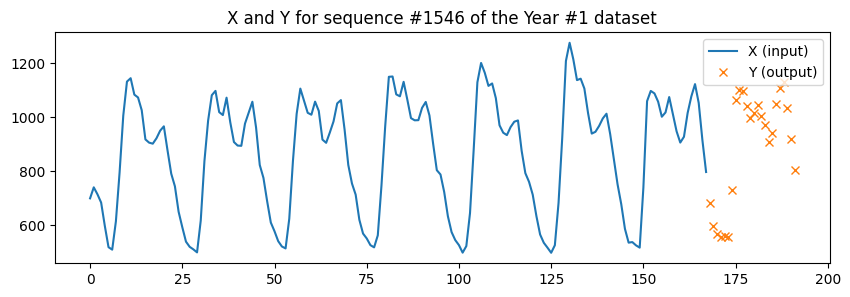

In [32]:
random_ix = np.random.choice(X.shape[0])
f, ax = plt.subplots(1,figsize=(10,3))
ax.plot(np.arange(T),X[0], label='X (input)')
ax.plot(np.arange(T,T+H),Y[0], 'x', label = 'Y (output)')
ax.set_title(f'X and Y for sequence #{random_ix} of the Year #1 dataset');
ax.legend();

These sequences are not normalized yet, and we need to split them into training and validation. We first perform the latter task and then we use ```scale_sequences``` to perform the scaling. Is important to use the scaler "fitted" for the training dataset to scale tha validation dataset and then the test dataset). Since the input and output variables are both water demand, we only need to fit one scaler. ```scale_sequences``` recognize whether to fit a scaler or use an existing one based on the arguments it receives when called.

In [33]:
# We keep track of indexes of train and validation.
X_tra, X_tst, Y_tra, Y_tst, ix_tra, ix_tst = train_test_split(
    X, Y, np.arange(X.shape[0]), test_size=0.30, shuffle=True, random_state=42)

# Split the existing test dataset into validation and test sets (50/50 split)
X_val, X_tst, Y_val, Y_tst, ix_val, ix_tst = train_test_split(
    X_tst, Y_tst, ix_tst, test_size=0.5, shuffle=True, random_state=42)


print(f"X_tra.shape: {X_tra.shape}, Y_tra.shape: {Y_tra.shape}")
print(f"X_val.shape: {X_val.shape}, Y_val.shape: {Y_val.shape}")
print(f"X_tst.shape: {X_tst.shape}, Y_tst.shape: {Y_tst.shape}")

X_tra.shape: (12129, 168), Y_tra.shape: (12129, 24)
X_val.shape: (2599, 168), Y_val.shape: (2599, 24)
X_tst.shape: (2600, 168), Y_tst.shape: (2600, 24)


Now we scale all data. Remember: <u>you "fit" the scaler using training data </u>; when you develop your machine learning models, you have to assume that you have no information on validation and test data.

In [34]:
# scale/normalize
X_tra, scaler = scale_sequences(X_tra, scaler_type='standard')
Y_tra = scale_sequences(Y_tra, scaler)
X_val = scale_sequences(X_val, scaler)
Y_val = scale_sequences(Y_val, scaler)
X_tst = scale_sequences(X_tst, scaler)
Y_tst = scale_sequences(Y_tst, scaler)

## Definition of MultiLayer Perceptron and Simple Recurrent Neural Network

To load the models trained in Part 1, <u>we need the same classes</u> implemented there. Here we do it for MLP and SimpleRNN. You can do the same for other classes, if you implemented them.

In [35]:
class MLP(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(MLP, self).__init__()
        # Define the layers of the network
        self.fc1 = nn.Linear(T, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Define the forward pass
        x = F.tanh(self.fc1(x))  # Activation function (ReLU) after first layer
        x = F.tanh(self.fc2(x))  # Activation function (ReLU) after second layer
        x = self.fc3(x)          # Output layer
        return x

In [39]:
class SimpleRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        # RNN layer
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)

        # Output layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Reshape input to have feature dimension of 1
        x = x.unsqueeze(-1)   # Assuming input x has shape (batch, sequence)

        # RNN layer
        x, hn = self.rnn(x)   # We do not need the hidden states hn

        # Select the output of the last time step
        x = x[:, -1, :]

        # Output layer
        x = self.fc(x)

        return x

### Datasets and Data Loaders


We create the `TensorDatasets` and the `DataLoaders`.

In [40]:
train_dataset = TensorDataset(torch.tensor(X_tra, dtype=torch.float32), torch.tensor(Y_tra, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(Y_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_tst, dtype=torch.float32), torch.tensor(Y_tst, dtype=torch.float32 ))

In [41]:
batch_size = 256      # You can modify this based on your requirements

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Recursive multi-step ahead prediction

Here, we will evaluate how the models built for one-step ahead prediction perform when used recursively to forecast over longer horizons.

### Function for recursive multi-step ahead prediction 

The code below defines the `evaluate_model_multistep` function that performs recursive multi-step ahead prediction and evaluates model's performance.

Below is a step by step description of each line of code, divided in parts. 

<u>Function Definition</u>
- `model`: The neural network model to be evaluated.
- `test_loader`: A DataLoader containing the test dataset.
- `criterion`: The loss function for evaluating performance.
- `device`: The computing device (CPU/GPU) for model evaluation.
- `T`: The length of the input sequence.
- `H`: The number of prediction steps ahead.

<u>Model Evaluation Setup</u>
- `model.eval()`: Sets the model to evaluation mode.
- `test_loss`: Accumulates the total loss over the test dataset.

<u>Storing Predictions and Targets</u>
- `all_predictions` and `all_targets`: Lists to store predictions and actual targets from the test dataset.

<u>Evaluation Loop</u>
- `with torch.no_grad()`: Disables gradient calculations since they are not needed.
- Iterates over the test dataset to fetch batches of inputs and targets.

<u>Multi-Step Prediction Process</u>
- Iterates `H` times for each batch to simulate multi-step prediction.
- `step_inputs`: Current input for the model.
- `targets`: Actual target values for prediction.
- Updates `step_inputs` with the model's output for each step.

<u>Loss Calculation and Storage</u>
- After `H` steps, concatenates predictions to compare against actual targets.
- Adds batch loss to `test_loss`.
- Stores predictions and targets for each batch in respective lists.
  
<u>Final Output</u>
- Calculates and returns the average test loss.
- Returns tensors of all predictions and all targets from the test dataset.all targets from the test dataset.all targets from the test dataset.ased on past observations is crucial.


In [42]:
def evaluate_model_multistep(model, test_loader, criterion, device, T, H):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0

    all_predictions = []  # List to store all batch predictions
    all_targets = []      # List to store all batch targets

    with torch.no_grad():  # No need to track gradients during evaluation
        for initial_inputs, initial_targets in test_loader:
            step_inputs = initial_inputs.to(device)
            targets = initial_targets.to(device)

            # Holds predictions for comparison with targets
            predictions = []

            # Iterate for H steps
            for h in range(H):
                outputs = model(step_inputs)
                predictions.append(outputs)

                # Reshape or expand outputs to be 3D: [batch_size, 1, features]
                next_input = outputs.unsqueeze(-1).squeeze(1)  # Adjust the dimensions as necessary

                # Update step_inputs by sliding the window: remove the oldest input and add the new output
                # Ensure that step_inputs and next_input are correctly shaped for concatenation
                step_inputs = torch.cat((step_inputs[:, 1:], next_input), dim=1)

            # Concatenate predictions and calculate loss against the entire target sequence
            batch_predictions  = torch.stack(predictions, dim=1).squeeze(-1)  # Squeeze the last dimension

            loss = criterion(batch_predictions , targets)
            test_loss += loss.item()

            # Store batch predictions and targets
            all_predictions.append(batch_predictions.cpu())
            all_targets.append(targets.cpu())

    # Concatenate all batch predictions and targets into tensors
    all_predictions = torch.cat(all_predictions, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    avg_test_loss = test_loss / len(test_loader)
    return avg_test_loss, all_predictions, all_targets

### Load the MLP and RNN models for one-step ahead prediction

Make sure to point at the <u>correct folder path</u> in the hard drive to load the models. Also, make sure you use the <u>same number of neurons</u> when instantiating the architecture.

In [43]:
# Find best models according to Part 1
df_results = pd.read_csv('results.csv', index_col = 0)
df_results.head()

,ann_type,hidden_size,num_epochs,lr,batch_size,model_name,tr_loss,val_loss,elapsed_time,trainable_params
0,MLP,32,500,0.0001,256,model_000,0.010383,0.014426,106.143285,6497
1,MLP,32,500,0.0005,256,model_001,0.007640,0.012952,107.072412,6497
2,MLP,32,500,0.0010,256,model_002,0.008035,0.011601,102.084066,6497
3,MLP,64,500,0.0001,256,model_003,0.009428,0.014955,105.793990,15041
4,MLP,64,500,0.0005,256,model_004,0.006980,0.012356,108.309417,15041


In [44]:
df_MLP = df_results[df_results['ann_type']=='MLP'].reset_index(drop=True)
ix_MLP = df_MLP['val_loss'].idxmin()
MLP_load_path, n_hidden_MLP = f"{df_MLP.iloc[ix_MLP]['model_name']}.pth", df_MLP.iloc[ix_MLP]['hidden_size']
print(MLP_load_path)

model_014.pth


In [45]:
df_RNN = df_results[df_results['ann_type']=='SimpleRNN'].reset_index(drop=True)
ix_RNN = df_RNN['val_loss'].idxmin()
RNN_load_path, n_hidden_RNN = f"{df_RNN.iloc[ix_RNN]['model_name']}.pth", df_RNN.iloc[ix_RNN]['hidden_size']
print(RNN_load_path)

model_023.pth


In [46]:
model_MLP = MLP(n_hidden_MLP,1).to(device)
model_MLP.load_state_dict(torch.load('./models/' + MLP_load_path, map_location=torch.device(device)))

<All keys matched successfully>

In [47]:
model_RNN = SimpleRNN(int(n_hidden_RNN),1).to(device)
model_RNN.load_state_dict(torch.load('./models/' + RNN_load_path, map_location=torch.device(device)))

<All keys matched successfully>

### Predict over the extended horizon on the test dataset

In [48]:
criterion = nn.MSELoss()  # Or another appropriate loss function

avg_test_loss_MLP, predictions_MLP, _ = evaluate_model_multistep(model_MLP, test_loader, criterion, device, T, H)
avg_test_loss_RNN, predictions_RNN, targets = evaluate_model_multistep(model_RNN, test_loader, criterion, device, T, H)

### Comparison of performance 

In [49]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"MLP --> num. trainable parameters:{count_parameters(model_MLP):8d} | Test loss: {avg_test_loss_MLP:.4f}")
print(f"RNN --> num. trainable parameters:{count_parameters(model_RNN):8d} | Test loss: {avg_test_loss_RNN:.4f}")

MLP --> num. trainable parameters:  349697 | Test loss: 0.0572
RNN --> num. trainable parameters:   16897 | Test loss: 0.0981


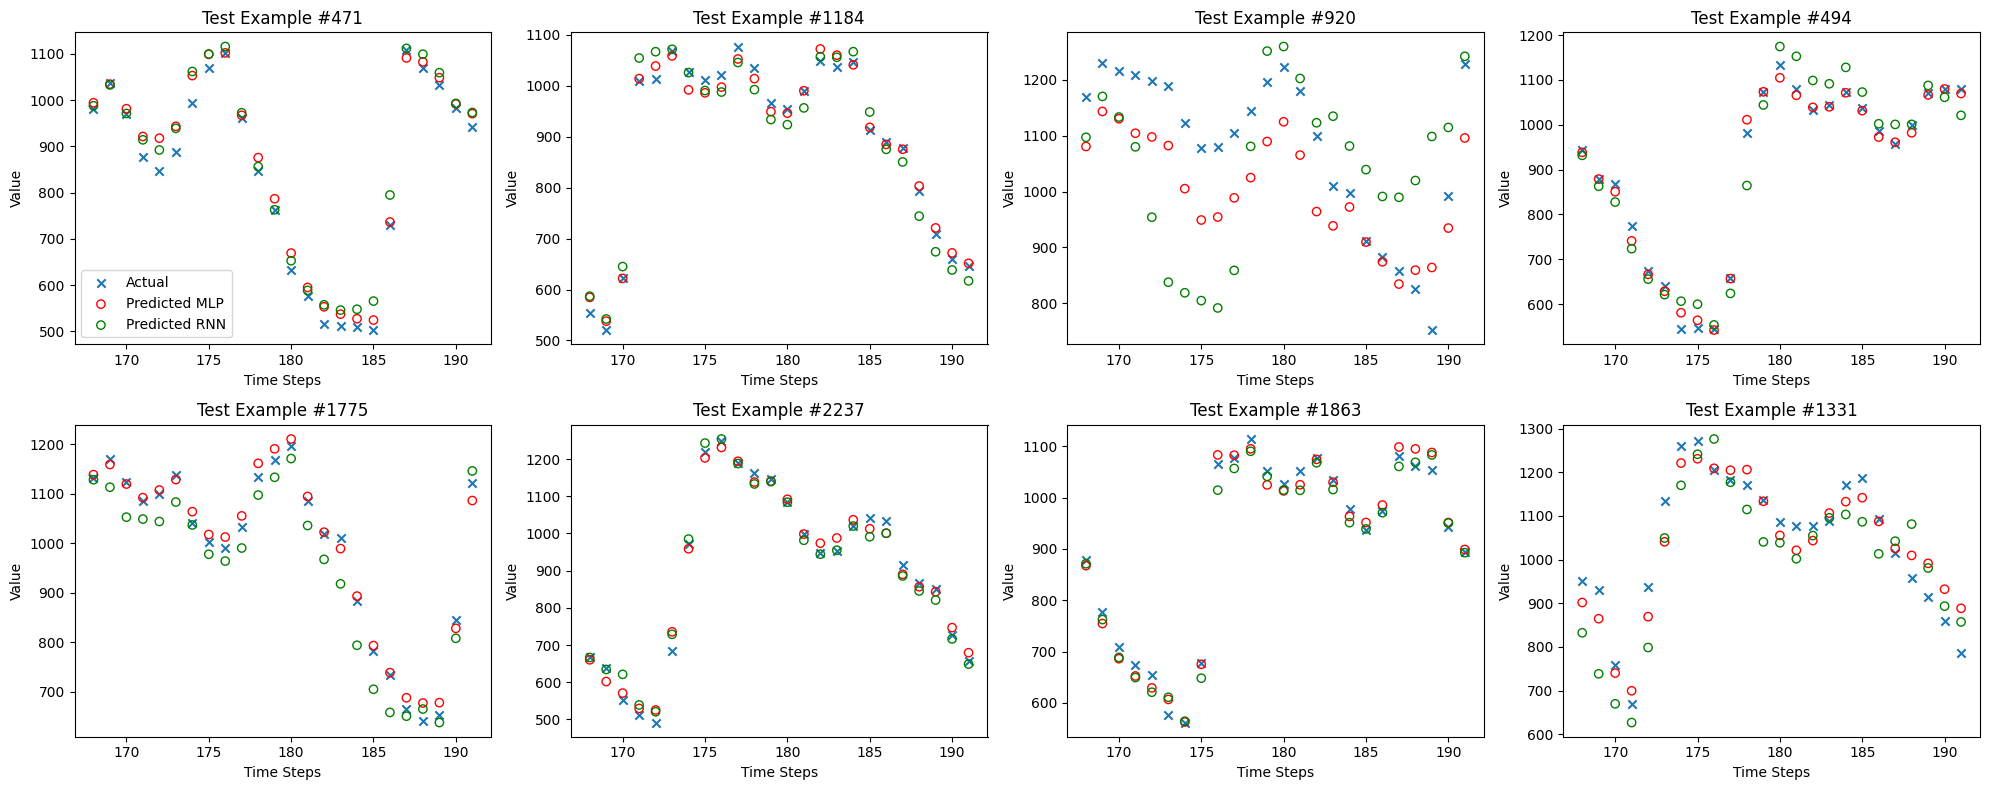

In [50]:
# Create subplots
f, axes = plt.subplots(2, 4, figsize=(20, 8))

for ix,ax in enumerate(axes.reshape(-1)):
    random_index = random.randint(0, len(targets) - 1)
    # Rescaling targets and predictions
    target_rescaled = scaler.inverse_transform(targets[random_index].cpu().numpy().flatten().reshape(-1, 1)).flatten()
    prediction_MLP_rescaled = scaler.inverse_transform(predictions_MLP[random_index].cpu().numpy().flatten().reshape(-1, 1)).flatten()
    prediction_RNN_rescaled = scaler.inverse_transform(predictions_RNN[random_index].cpu().numpy().flatten().reshape(-1, 1)).flatten()

    # Plotting prediction vs target
    ax.scatter(np.arange(T, T+H), target_rescaled, marker='x', label='Actual')
    ax.scatter(np.arange(T, T+H), prediction_MLP_rescaled, marker='o', facecolors='none', edgecolors='r', label='Predicted MLP')
    ax.scatter(np.arange(T, T+H), prediction_RNN_rescaled, marker='o', facecolors='none', edgecolors='g', label='Predicted RNN')

    ax.set_title(f'Test Example #{random_index}')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Value')
    if ix == 0:
        ax.legend()

f.tight_layout()

## Assignments

1. **Comparison between RNN and MLP for recursive prediction**
  - Critically analyze the performance differences between the RNN and MLP architecture for the recursive prediction. Which model yielded better results? How does this compare with the results you obtained for Part 1, i.e., one-step ahead prediction? Discuss the reasons for this performance difference.

 > <u>Answer</u>. The MLP keeps performing better than the RNN. The gap in performance is slightly larger. This is expected since errors may accumulate as we feed the predictions recursively to forecast further in the future. That said, the predictions are still quite close to the observed values in both cases. 

2. **Develop MLP and RNN models for 24-steps ahead forecasting**
  - Extend the MLP and RNN models that you developed in Part 1 for 24-steps ahead prediction. 
  - Minimal changes to the existing implementations are required:
    - Make sure `output_size=24`; 
    - The training loop function used in Part 1 can be reused for this task;
    - Similarly, you have to use the same function of Part 1 for model evaluation;
    - `evaluate_model_multistep` will not work!
  - Discuss the results, also by comparing them against the recursive approach in the walkthorugh.
3. **Deeper RNNs**
  - Adapt the simple RNN model to an RNN with two recurrent layers; check if this captures better the temporal dependencies in the data.
    - Modify the `SimpleRNN` class to a `TwoLayerRNN` by setting `num_layers=2` in the RNN layer (`nn.RNN`). This change enables the network to have two RNN layers, potentially enhancing its capacity to capture complex patterns in the data. See [here](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html) for further info.
  -  After trying a few alternative configurations (e.g., more or less neurons) and tweaking some training hyperparameters (e.g., learning rate, number of epochs), discuss whether the deeper architecture better captures the temporal relationships.

 
4. **Develop an Encoder-Decoder RNN model for 24-steps ahead forecasting**
  - Adapt the simple RNN model to an RNN encoder-decoder framework, focusing on managing hidden states for producing the 24-steps ahead forecasts.
    - Encoder Modifications: Retain the basic structure of the `SimpleRNN` class. This time, the hidden states `hn` from the RNN layer are crucial as they capture the *context*.
    - Decoder Design: In the decoder, use the context in the final hidden state from the encoder as the initial state. Generate the forecast sequence step by step.
  - After trying a few version of this architecture and tweaking some hyperparameters, discuss whether the encoder-decoder better captures the temporal relationships.

### Develop MLP and RNN models for 24-steps ahead forecasting

In [51]:
# Consider multiple combinations with a "grid search approach"
ANN_type = ['MLP','SimpleRNN']
hidden_size = [64, 128, 256]
num_epochs = [500] # we train for longer
lr = [0.0001, 0.0005, 0.001]
batch_size = [256]

all_combinations = list(itertools.product(*[ANN_type,hidden_size,num_epochs,lr,batch_size]))

# Create dataframe storing results for different combination of hyperparameters
res_df = pd.DataFrame(index=np.arange(len(all_combinations)),
                          columns=['ann_type','hidden_size','num_epochs','lr','batch_size','model_name',
                                   'tr_loss','val_loss','elapsed_time','trainable_params'])

res_df.head()

,ann_type,hidden_size,num_epochs,lr,batch_size,model_name,tr_loss,val_loss,elapsed_time,trainable_params
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0

    with torch.no_grad():  # No need to track gradients during evaluation
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    return avg_test_loss

def train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, save_path, echo_iter = 20):
    best_val_loss = float("inf")  # Track the best validation loss
    train_losses = []
    val_losses = []

    start_time = time.time()  # Start training time

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        total_train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Phase
        avg_val_loss = evaluate_model(model, val_loader, criterion, device)
        val_losses.append(avg_val_loss)

        # Save Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)

        if echo_iter > 0:
            if (epoch + 1) % echo_iter == 0:
                print(f'Epoch {epoch+1}/{num_epochs}', f'Train Loss: {avg_train_loss:.4f}, '
                      f'Validation Loss: {avg_val_loss:.4f}', f'Best Validation Loss: {best_val_loss:.4f}')
                
    train_time = time.time() - start_time
    if echo_iter > 0:
        print("Training complete.")
    return train_losses, val_losses, best_val_loss, train_time

In [54]:
# change H to 24
H = 24

histories = [] # store training histories for each model

for i, combination in tqdm(enumerate(all_combinations), total=len(all_combinations)):
    # retrieve and store hyperparameters
    ANN_type_, hidden_size_, num_epochs_, lr_, batch_size_ = combination
    res_df.loc[i,['ann_type','hidden_size','num_epochs','lr','batch_size']] = combination

    # create and store model name
    model_name = f"model_{i:03d}"
    res_df.loc[i,['model_name']] = model_name
    
    # create model
    if ANN_type_ == 'MLP':        
        this_model = MLP(hidden_size_, H).to(device)
    elif ANN_type_ == 'SimpleRNN':        
        this_model = SimpleRNN(hidden_size_, H).to(device)
    else:
        raise Exception("Model Not Found!")
        
    res_df.loc[i,'trainable_params'] = count_parameters(this_model)

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(this_model.parameters(), lr=lr_)
    save_path = f'./models_part2/{model_name}.pth'
    train_loader = DataLoader(train_dataset, batch_size=batch_size_, shuffle=True)

    train_losses, val_losses, _, elapsed_time = train_and_validate(this_model, train_loader, val_loader, criterion, optimizer, num_epochs_, device, save_path, echo_iter = 0)

    best_iter = np.array(val_losses).argmin()
    
    res_df.loc[i,['tr_loss','val_loss','elapsed_time']] = train_losses[best_iter], val_losses[best_iter], elapsed_time

    histories.append({'train_losses': train_losses, 'val_losses': val_losses})

100%|██████████| 18/18 [57:19<00:00, 191.07s/it]


In [55]:
res_df.to_csv('results_part2_24h.csv')

ann_type             SimpleRNN
hidden_size                256
num_epochs                 500
lr                      0.0005
batch_size                 256
model_name           model_016
tr_loss               0.014785
val_loss              0.017734
elapsed_time        236.485782
trainable_params         72472
Name: 16, dtype: object


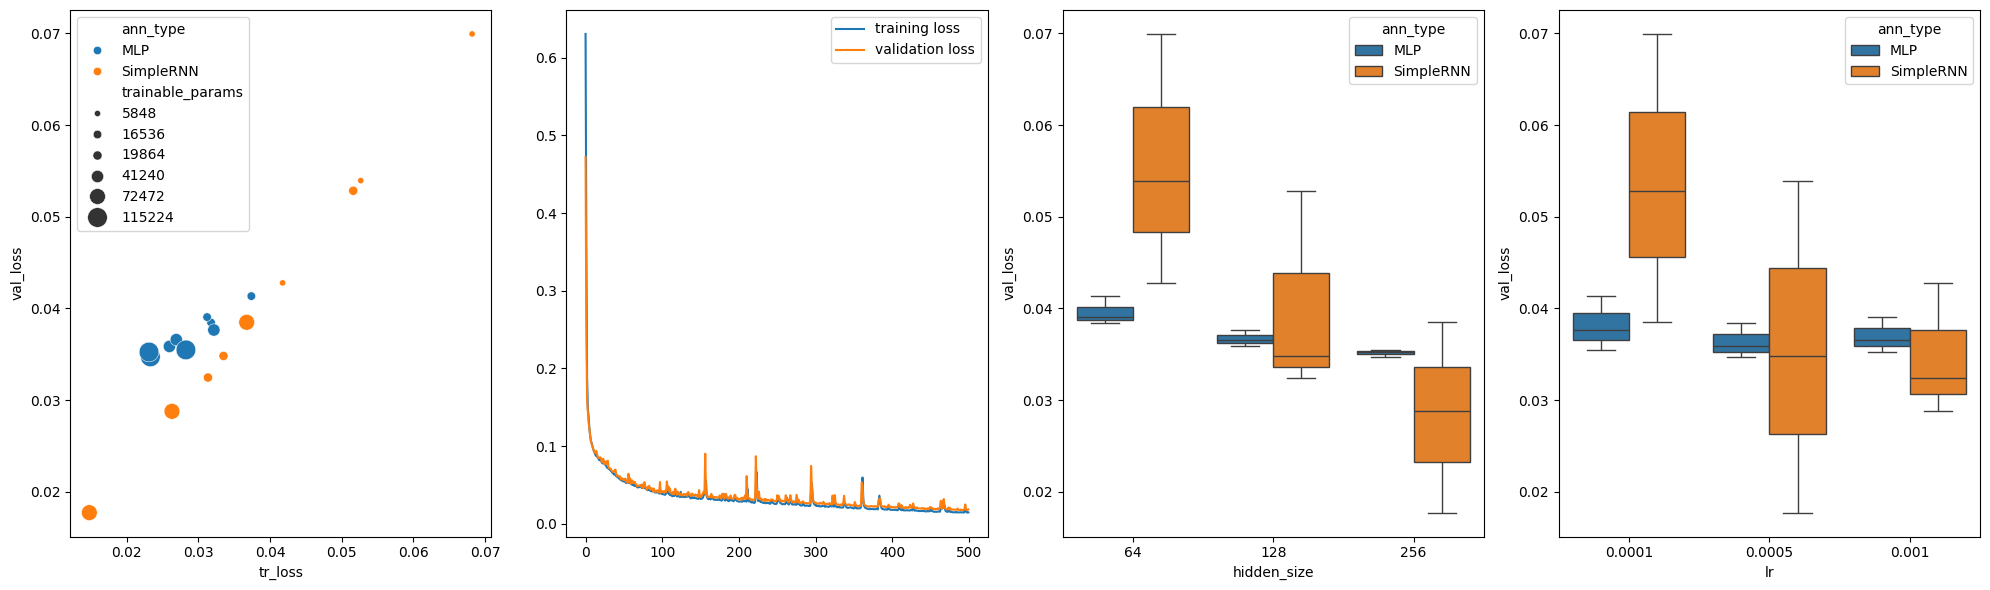

In [56]:
f, axes = plt.subplots(1,4,figsize=(20,6))
sns.scatterplot(
    data=res_df, x="tr_loss", y="val_loss", size="trainable_params", hue="ann_type", sizes=(20, 200), legend="full", ax=axes[0]);

best_model_ix = res_df['val_loss'].astype(float).idxmin()
print(res_df.loc[best_model_ix])
axes[1].plot(histories[best_model_ix]['train_losses'], label='training loss')
axes[1].plot(histories[best_model_ix]['val_losses'], label='validation loss')
axes[1].legend()

sns.boxplot(x='hidden_size',y='val_loss', hue='ann_type', data=res_df, ax = axes[2])
sns.boxplot(x='lr',y='val_loss', hue='ann_type', data=res_df, ax = axes[3])

f.tight_layout()

In [57]:
df_MLP = res_df[res_df['ann_type']=='MLP'].reset_index(drop=True)
ix_MLP = df_MLP['val_loss'].idxmin()
MLP_load_path, n_hidden_MLP = f"{df_MLP.iloc[ix_MLP]['model_name']}.pth", df_MLP.iloc[ix_MLP]['hidden_size']
print(MLP_load_path)

model_007.pth


In [58]:
df_RNN = res_df[res_df['ann_type']=='SimpleRNN'].reset_index(drop=True)
ix_RNN = df_RNN['val_loss'].idxmin()
RNN_load_path, n_hidden_RNN = f"{df_RNN.iloc[ix_RNN]['model_name']}.pth", df_RNN.iloc[ix_RNN]['hidden_size']
print(RNN_load_path)

model_016.pth


In [59]:
model_MLP = MLP(n_hidden_MLP,H).to(device)
model_MLP.load_state_dict(torch.load('./models_part2/' + MLP_load_path, map_location=torch.device(device)))

<All keys matched successfully>

In [60]:
model_RNN = SimpleRNN(int(n_hidden_RNN),H).to(device)
model_RNN.load_state_dict(torch.load('./models_part2/' + RNN_load_path, map_location=torch.device(device)))

<All keys matched successfully>

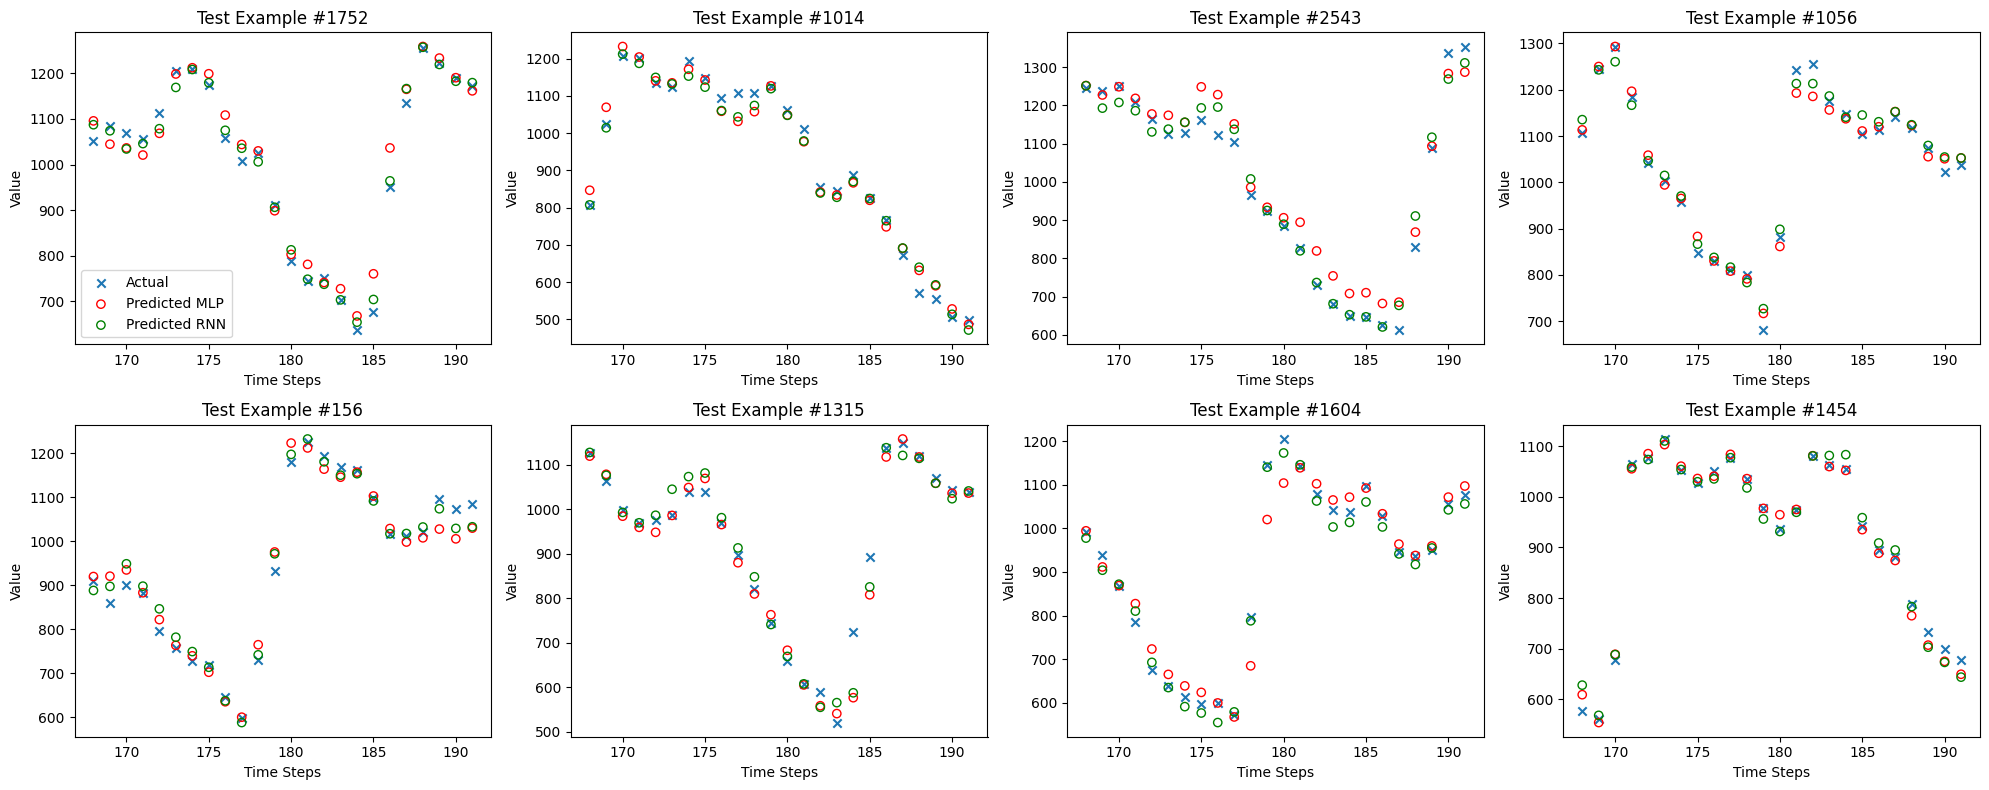

In [69]:
def compareModels(model1, model2):
    f, axes = plt.subplots(2, 4, figsize=(20, 8))
    
    for ix,ax in enumerate(axes.reshape(-1)):
        random_index = random.randint(0, len(targets) - 1)

        inputs, target = test_dataset[random_index]
        inputs, target = inputs.to(device).unsqueeze(0), target.to(device).unsqueeze(0)

        model1.eval()
        model2.eval()
        predictions_1 = model1(inputs)
        predictions_2 = model2(inputs)
        
        # Rescaling targets and predictions
        target_rescaled = scaler.inverse_transform(targets[random_index].cpu().numpy().flatten().reshape(-1, 1)).flatten()
        predictions_1_rescaled = scaler.inverse_transform(predictions_1.detach().cpu().numpy().flatten().reshape(-1, 1)).flatten()
        predictions_2_rescaled = scaler.inverse_transform(predictions_2.detach().cpu().numpy().flatten().reshape(-1, 1)).flatten()
    
        # Plotting prediction vs target
        ax.scatter(np.arange(T, T+H), target_rescaled, marker='x', label='Actual')
        ax.scatter(np.arange(T, T+H), predictions_1_rescaled, marker='o', facecolors='none', edgecolors='r', label='Predicted MLP')
        ax.scatter(np.arange(T, T+H), predictions_2_rescaled, marker='o', facecolors='none', edgecolors='g', label='Predicted RNN')
    
        ax.set_title(f'Test Example #{random_index}')
        ax.set_xlabel('Time Steps')
        ax.set_ylabel('Value')
        if ix == 0:
            ax.legend()
    
    f.tight_layout()

compareModels(model_MLP, model_RNN)

The sequential inductive bias of the RNN seems to produce better results when predicting multiple time-steps concurrently. The performance of the RNN are better than what achieved before with recursive iteration. On the other hand, the MLP struggles to scale the prediction over a longer time horizon. 

### DeeperRNN

In [70]:
class DeepSimpleRNN(nn.Module):
    def __init__(self, hidden_size, output_size, num_layers):
        super(DeepSimpleRNN, self).__init__()
        # RNN layer
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)

        # Output layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Reshape input to have feature dimension of 1
        x = x.unsqueeze(-1)   # Assuming input x has shape (batch, sequence)

        # RNN layer
        x, hn = self.rnn(x)   # We do not need the hidden states hn

        # Select the output of the last time step
        x = x[:, -1, :]

        # Output layer
        x = self.fc(x)

        return x

In [75]:
# Consider multiple combinations with a "grid search approach" -- feel free to add more parameter options to explore!
ANN_type = ['DeepSimpleRNN']
hidden_size = [128, 256]
num_epochs = [500] # we train for longer
lr = [0.0005]
batch_size = [256]

all_combinations = list(itertools.product(*[ANN_type,hidden_size,num_epochs,lr,batch_size]))

# Create dataframe storing results for different combination of hyperparameters
res_df = pd.DataFrame(index=np.arange(len(all_combinations)),
                          columns=['ann_type','hidden_size','num_epochs','lr','batch_size','model_name',
                                   'tr_loss','val_loss','elapsed_time','trainable_params'])

res_df.head()

,ann_type,hidden_size,num_epochs,lr,batch_size,model_name,tr_loss,val_loss,elapsed_time,trainable_params
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
histories = [] # store training histories for each model

for i, combination in tqdm(enumerate(all_combinations), total=len(all_combinations)):
    # retrieve and store hyperparameters
    ANN_type_, hidden_size_, num_epochs_, lr_, batch_size_ = combination
    res_df.loc[i,['ann_type','hidden_size','num_epochs','lr','batch_size']] = combination

    # create and store model name
    model_name = f"model_{i:03d}"
    res_df.loc[i,['model_name']] = model_name
    
    # create model
    if ANN_type_ == 'DeepSimpleRNN':        
        this_model = DeepSimpleRNN(hidden_size_, H, num_layers=2).to(device)
    else:
        raise Exception("Model Not Found!")
        
    res_df.loc[i,'trainable_params'] = count_parameters(this_model)

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(this_model.parameters(), lr=lr_)
    save_path = f'./models_part2_deepRNN/{model_name}.pth'
    train_loader = DataLoader(train_dataset, batch_size=batch_size_, shuffle=True)

    train_losses, val_losses, _, elapsed_time = train_and_validate(this_model, train_loader, val_loader, criterion, optimizer, num_epochs_, device, save_path, echo_iter = 0)

    best_iter = np.array(val_losses).argmin()
    
    res_df.loc[i,['tr_loss','val_loss','elapsed_time']] = train_losses[best_iter], val_losses[best_iter], elapsed_time

    histories.append({'train_losses': train_losses, 'val_losses': val_losses})

100%|██████████| 2/2 [16:21<00:00, 490.77s/it]


In [77]:
res_df.to_csv('results_part2_24h_deepRNN.csv')

ann_type            DeepSimpleRNN
hidden_size                   256
num_epochs                    500
lr                         0.0005
batch_size                    256
model_name              model_001
tr_loss                   0.00424
val_loss                 0.006226
elapsed_time            673.77997
trainable_params           204056
Name: 1, dtype: object


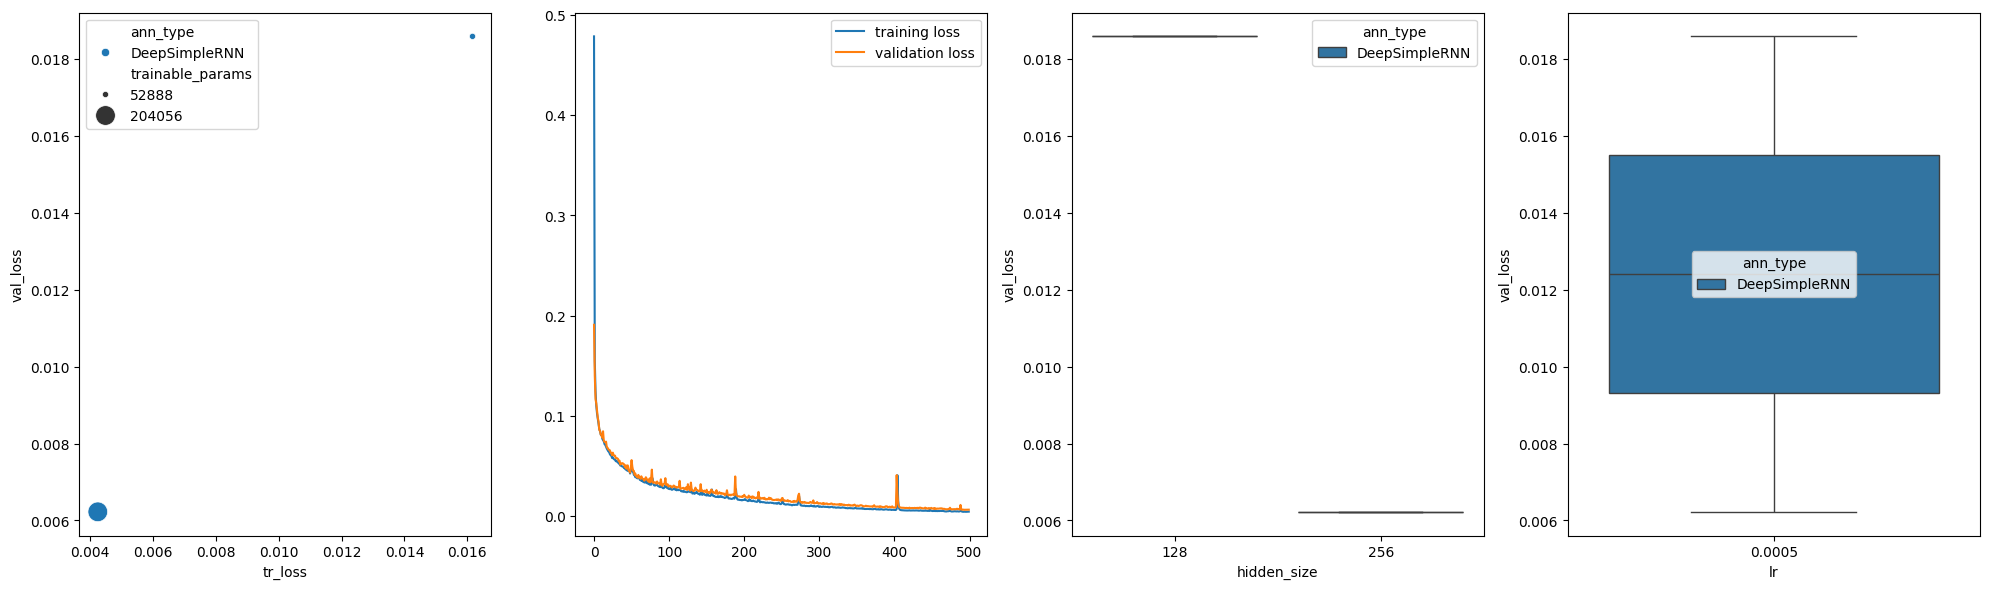

In [78]:
f, axes = plt.subplots(1,4,figsize=(20,6))
sns.scatterplot(
    data=res_df, x="tr_loss", y="val_loss", size="trainable_params", hue="ann_type", sizes=(20, 200), legend="full", ax=axes[0]);

best_model_ix = res_df['val_loss'].astype(float).idxmin()
print(res_df.loc[best_model_ix])
axes[1].plot(histories[best_model_ix]['train_losses'], label='training loss')
axes[1].plot(histories[best_model_ix]['val_losses'], label='validation loss')
axes[1].legend()

sns.boxplot(x='hidden_size',y='val_loss', hue='ann_type', data=res_df, ax = axes[2])
sns.boxplot(x='lr',y='val_loss', hue='ann_type', data=res_df, ax = axes[3])

f.tight_layout()

In [79]:
df_RNN = res_df[res_df['ann_type']=='DeepSimpleRNN'].reset_index(drop=True)
ix_RNN = df_RNN['val_loss'].idxmin()
RNN_load_path, n_hidden_RNN = f"{df_RNN.iloc[ix_RNN]['model_name']}.pth", df_RNN.iloc[ix_RNN]['hidden_size']
print(RNN_load_path)

model_001.pth


In [80]:
model_RNN = DeepSimpleRNN(int(n_hidden_RNN),H,num_layers=2).to(device)
model_RNN.load_state_dict(torch.load('./models_part2_deepRNN/' + RNN_load_path, map_location=torch.device(device)))

<All keys matched successfully>

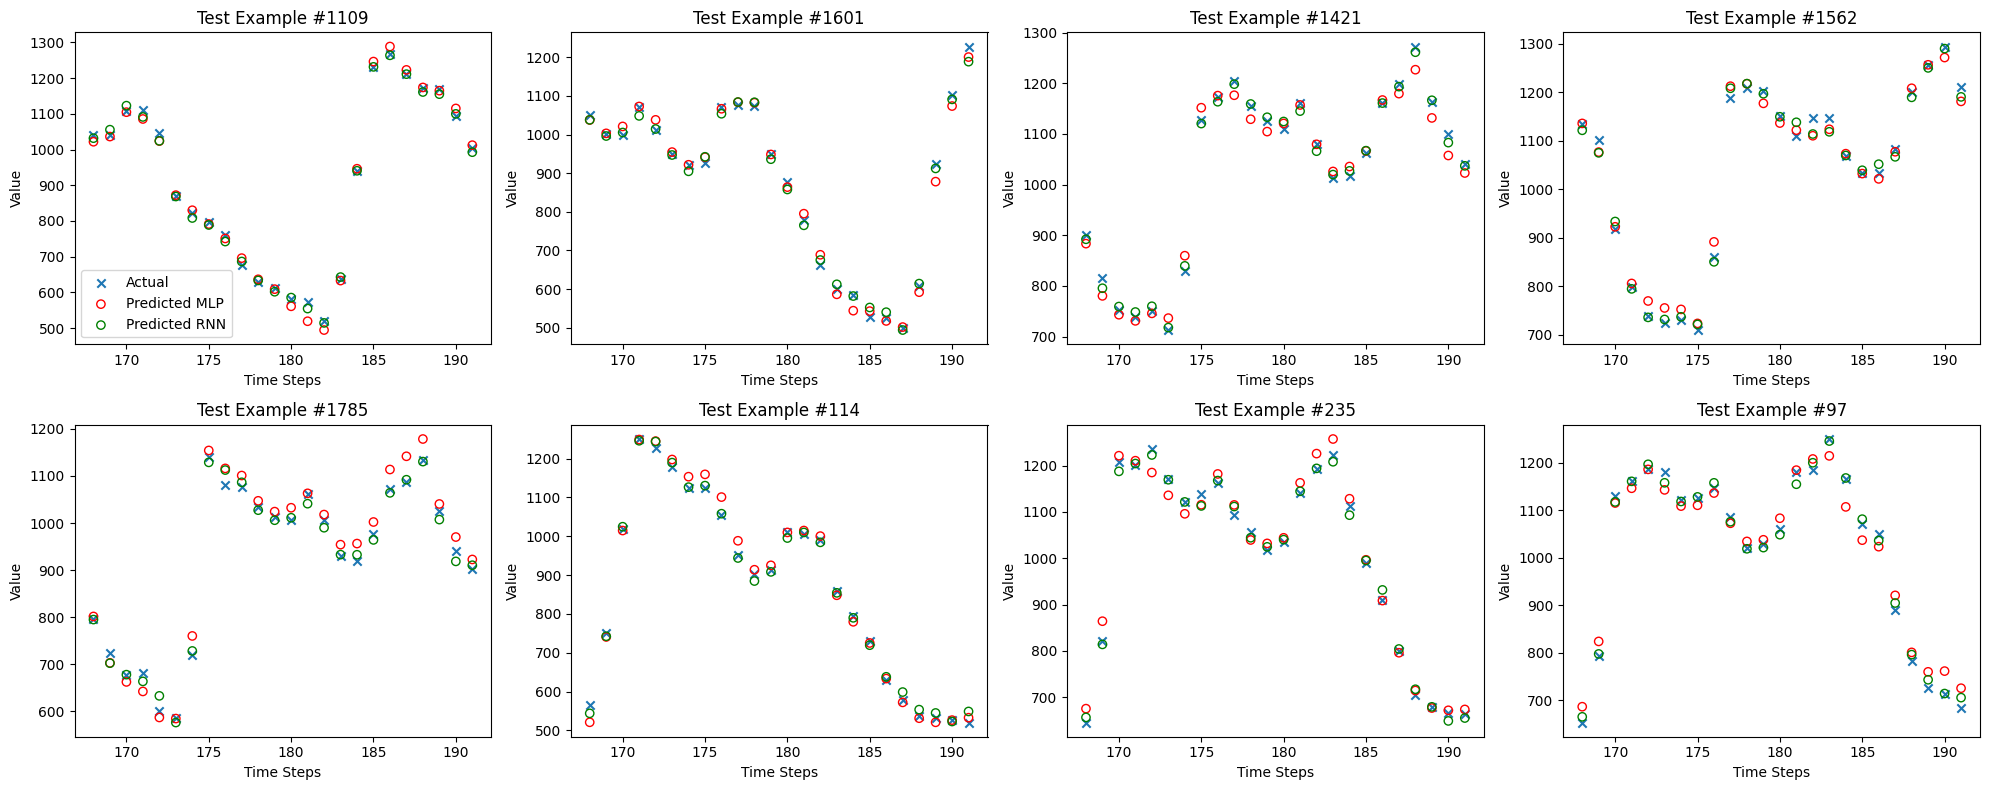

In [81]:
compareModels(model_MLP, model_RNN)

The deeper RNN has better performance, driving the errors further down. This may entail that hierarchical feature extraction can be beneficial. That said, the best models are now substantially bigger than the one used before, due to the extra layer. Therefore, one can not rule out that the increased complexity, along with the sequential inductive bias, is responsible for the better performance. 

### **Assignment 4 - Develop an Encoder-Decoder RNN model for 24-steps ahead forecasting**


In [82]:
class EncoderDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_length, num_layers=1, context_handling = 'both'):
        super(EncoderDecoderRNN, self).__init__()

        # Encoder RNN layer
        self.encoder_rnn = nn.RNN(1, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)

        # Decoder RNN layer
        # For simplicity, the decoder will have the same number of layers and hidden size
        self.decoder_rnn = nn.RNN(input_size = hidden_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)

        # Output layer
        # This "shared" MLP will be used for all the steps of the decoder; it will compute one output for each time step, by combining 
        # the relative outputs of all the decoder hidden units for that specific time step only.
        self.fc = nn.Linear(hidden_size, 1)

        # Store output size, needed for the decoding
        self.output_length = output_length

        # How to handle the context from the encoder for the decoder
        self.context_handling = context_handling

    def forward(self, x):
        # Encoder
        # Reshape input to have feature dimension equal to input_size
        # Assuming input x has shape (batch, sequence_length, input_size)
        # print(x.size())
        x = x.unsqueeze(-1)
        
        _ , context = self.encoder_rnn(x)   # Context is the last hidden state from the encoder
        
        # Decoder
        # We will use the context as the input for all time steps of the decoder.
        # Alternatively, we can provide it as the initial hidden state of the decoder network.
        # We need to repeat the decoder for as many steps as the output length, and then make sure to permute 
        # to respect the following order (batch, sequence_length, number of hidden units)
        if self.context_handling == 'input':
            decoder_input = context.repeat(self.output_length, 1, 1).permute(1, 0, 2)
            decoder_output, _ = self.decoder_rnn(decoder_input)
        elif self.context_handling == 'hidden':
            batch_size = context.size(1)
            hidden_size = context.size(2)
            # Create a tensor of zeros with the same shape as context.repeat(24, 1, 1).permute(1, 0, 2)
            decoder_input = torch.zeros(batch_size, self.output_length, hidden_size, device=context.device)            
            decoder_output, _ = self.decoder_rnn(decoder_input, context)
        elif self.context_handling == 'both':
            decoder_input = context.repeat(self.output_length, 1, 1).permute(1, 0, 2)
            decoder_output, _ = self.decoder_rnn(decoder_input, context)    
        else:
            raise Exception("Context Handling Mode Not Found!")

        # Combine outputs of all units for each time step with the shared fc; reshape and squeeze to match target data for loss computation.
        output = self.fc(decoder_output).permute(0, 2, 1).squeeze()

        return output


In [83]:
# Consider multiple combinations with a "grid search approach"
ANN_type = ['SimpleRNN','DeepSimpleRNN','EncoderDecoderRNN']
hidden_size = [256]
context_handling = ['both'] # this matters only for the encoder decoder
num_epochs = [500] # we train for longer
lr = [0.0005]
batch_size = [256]

all_combinations = list(itertools.product(*[ANN_type,hidden_size,num_epochs,lr,batch_size,context_handling]))

# Create dataframe storing results for different combination of hyperparameters
res_df = pd.DataFrame(index=np.arange(len(all_combinations)),
                          columns=['ann_type','hidden_size','num_epochs','lr','batch_size','context_handling','model_name',
                                   'tr_loss','val_loss','elapsed_time','trainable_params'])

res_df.head()

,ann_type,hidden_size,num_epochs,lr,batch_size,context_handling,model_name,tr_loss,val_loss,elapsed_time,trainable_params
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
histories = [] # store training histories for each model

for i, combination in tqdm(enumerate(all_combinations), total=len(all_combinations)):
    # retrieve and store hyperparameters
    ANN_type_, hidden_size_, num_epochs_, lr_, batch_size_, context_handling_ = combination
    res_df.loc[i,['ann_type','hidden_size','num_epochs','lr','batch_size','context_handling']] = combination

    # create and store model name
    model_name = f"model_{i:03d}"
    res_df.loc[i,['model_name']] = model_name
    
    # create model
    if ANN_type_ == 'EncoderDecoderRNN':        
        this_model = EncoderDecoderRNN(hidden_size_, H, num_layers=1, context_handling=context_handling_).to(device)
    elif ANN_type_ == 'SimpleRNN':        
        this_model = SimpleRNN(hidden_size_, H).to(device)
    elif ANN_type_ == 'DeepSimpleRNN':        
        this_model = DeepSimpleRNN(hidden_size_, H,  num_layers=2).to(device)
    else:
        raise Exception("Model Not Found!")
        
    res_df.loc[i,'trainable_params'] = count_parameters(this_model)

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(this_model.parameters(), lr=lr_)
    save_path = f'./models_part2_encdec/{model_name}.pth'
    train_loader = DataLoader(train_dataset, batch_size=batch_size_, shuffle=True)

    train_losses, val_losses, _, elapsed_time = train_and_validate(this_model, train_loader, val_loader, criterion, optimizer, num_epochs_, device, save_path, echo_iter = 0)

    best_iter = np.array(val_losses).argmin()
    
    res_df.loc[i,['tr_loss','val_loss','elapsed_time']] = train_losses[best_iter], val_losses[best_iter], elapsed_time

    histories.append({'train_losses': train_losses, 'val_losses': val_losses})

100%|██████████| 3/3 [26:15<00:00, 525.02s/it]


In [89]:
res_df.to_csv('results_part2_24h_encdec.csv')

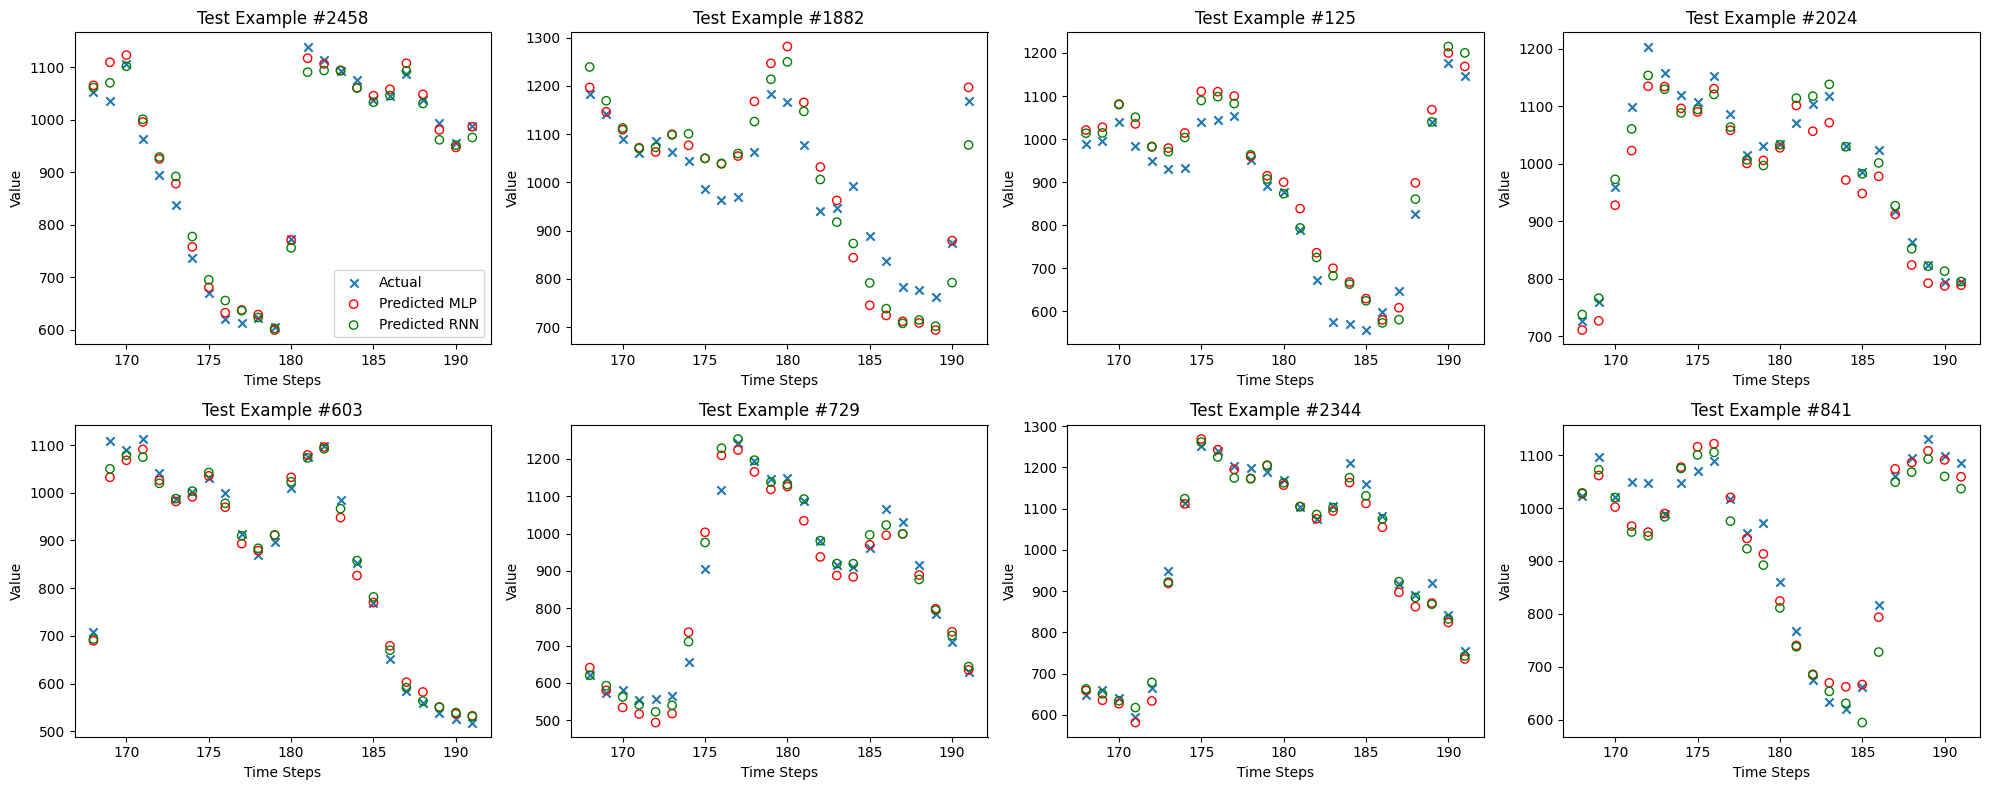

In [90]:
compareModels(model_MLP, this_model)

The encoder-decoder architecture improves over the SimpleRNN. However, the DeepSimpleRNN is more effective. This may suggest that for this specific case with RNNs, the more correct implementation of the sequential inductive bias given by linking dynamically the 24 predictions in the decoder, is less important than building more complex features by stacking two layers. This could change when using more complex RNNs such as LSTMs or GRUs, or by having more data.